# Notebook 04 — Storage & Queries
## FinPulse: Precious Metals Trading Intelligence Pipeline

**Objective:** Document the storage architecture and demonstrate advanced querying capabilities across both MongoDB (document store) and Neo4j (graph store). This notebook satisfies **FAQ 6** — data must be modeled and stored in one or more DBMS, with at least two queries on the data.

**What this notebook covers:**
- Storage architecture overview (dual-DBMS rationale)
- MongoDB document model — schema documentation & indexing strategy
- Neo4j graph model — node/relationship schema documentation
- Advanced MongoDB queries (aggregation pipelines, complex finds)
- Advanced Neo4j Cypher queries (graph traversals, pattern matching)
- Cross-database query comparison

---
**Corrections applied (v2):**
- `F_SENT`: fixed `avg_compound` → `mean` (MongoDB nested field)
- `F_RETURN`: fixed `daily_return` → `daily_return_pct`
- CQ1, CQ7: fixed `n.open` → `n.open_price` (Neo4j TradingDay property)
- CQ2, CQ5: fixed `s.avg_compound` → `s.sentiment_mean` (Neo4j DailySentiment property)

## 0. Environment Setup

In [1]:
%pip install py2neo pymongo pandas tabulate matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
from datetime import datetime, timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from py2neo import Graph
from IPython.display import display, Markdown

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')

os.makedirs('data/exports', exist_ok=True)

print('Imports complete.')

Imports complete.


In [3]:
# ── Database connections (Docker service names, NEVER localhost) ──
mongo_client = MongoClient('mongodb://mongo:27017')
db = mongo_client['finpulse']
print(f'MongoDB connected — databases: {mongo_client.list_database_names()}')
print(f'FinPulse collections: {db.list_collection_names()}')

graph = Graph(scheme='bolt', host='neo4j', port=7687, user='neo4j', password='password')
node_count = graph.run('MATCH (n) RETURN count(n) AS cnt').data()[0]['cnt']
print(f'Neo4j connected — total nodes: {node_count}')

MongoDB connected — databases: ['admin', 'config', 'finpulse', 'local', 'macro_finance_dm', 'mydb']
FinPulse collections: ['integrated_data', 'integration_errors', 'prices', 'analysis_results', 'quality_issues', 'news', 'quality_reports', 'acquisition_log']
Neo4j connected — total nodes: 585


In [4]:
# ══════════════════════════════════════════════════════════════════════
# DYNAMIC ASSET NAME & FIELD PATH DETECTION
# Auto-detects actual field names so all queries work regardless of
# schema variant. FIXED: corrected F_SENT (mean) and F_RETURN (daily_return_pct)
# ══════════════════════════════════════════════════════════════════════

# ── 1) Discover actual asset names ──
mongo_assets  = db['integrated_data'].distinct('asset_name')
print(f'MongoDB asset_name values: {mongo_assets}')

neo4j_assets  = [r['name'] for r in graph.run('MATCH (a:Asset) RETURN a.name AS name').data()]
print(f'Neo4j Asset.name values:   {neo4j_assets}')

GOLD   = next((a for a in mongo_assets if 'gold'   in a.lower()), mongo_assets[0] if mongo_assets else 'gold')
SILVER = next((a for a in mongo_assets if 'silver' in a.lower()), 'silver')
NEO_GOLD = next((a for a in neo4j_assets if 'gold' in a.lower()), neo4j_assets[0] if neo4j_assets else 'gold')

print(f'\nMongoDB filters:  GOLD={GOLD!r}, SILVER={SILVER!r}')
print(f'Neo4j filter:     NEO_GOLD={NEO_GOLD!r}')

# ── 2) Detect nested vs flat document structure ──
sample_int = db['integrated_data'].find_one({'asset_name': GOLD})
if not sample_int:
    sample_int = db['integrated_data'].find_one()

HAS_NESTED_OHLCV = 'ohlcv'      in sample_int if sample_int else False
HAS_NESTED_TECH  = 'technicals' in sample_int if sample_int else False
HAS_NESTED_SENT  = 'sentiment'  in sample_int if sample_int else False

# ── 3) Build MongoDB field-path variables ──
# FIX: F_CLOSE/HIGH/LOW/OPEN/VOLUME unchanged
F_CLOSE  = '$ohlcv.close'   if HAS_NESTED_OHLCV else '$close'
F_HIGH   = '$ohlcv.high'    if HAS_NESTED_OHLCV else '$high'
F_LOW    = '$ohlcv.low'     if HAS_NESTED_OHLCV else '$low'
F_OPEN   = '$ohlcv.open'    if HAS_NESTED_OHLCV else '$open'
F_VOLUME = '$ohlcv.volume'  if HAS_NESTED_OHLCV else '$volume'

# FIX: daily_return_pct (not daily_return) — matches NB03 storage
F_RETURN = '$technicals.daily_return_pct' if HAS_NESTED_TECH else '$daily_return_pct'
F_RSI    = '$technicals.rsi_14'           if HAS_NESTED_TECH else '$rsi_14'
F_VOL21  = '$technicals.volatility_21'    if HAS_NESTED_TECH else '$volatility_21'

# FIX: sentiment.mean (not sentiment.avg_compound) — matches NB03 storage
F_SENT = '$sentiment.mean'       if HAS_NESTED_SENT else '$sentiment_mean'
F_NCNT = '$sentiment.news_count' if HAS_NESTED_SENT else '$news_count'

# Dot-path versions (without $) for $match filters
P_SENT   = F_SENT.lstrip('$')
P_RETURN = F_RETURN.lstrip('$')
P_RSI    = F_RSI.lstrip('$')
P_VOL21  = F_VOL21.lstrip('$')
P_VOLUME = F_VOLUME.lstrip('$')

print(f'\nDocument structure:')
print(f'  Nested OHLCV:      {HAS_NESTED_OHLCV}  (close  → {F_CLOSE})')
print(f'  Nested technicals: {HAS_NESTED_TECH}  (return → {F_RETURN})')
print(f'  Nested sentiment:  {HAS_NESTED_SENT}  (sent   → {F_SENT})')
print(f'\nTop-level keys: {list(sample_int.keys()) if sample_int else "(none)"}')

MongoDB asset_name values: ['dxy', 'gold', 'silver', 'sp500']
Neo4j Asset.name values:   ['dxy', 'gold', 'silver', 'sp500']

MongoDB filters:  GOLD='gold', SILVER='silver'
Neo4j filter:     NEO_GOLD='gold'

Document structure:
  Nested OHLCV:      True  (close  → $ohlcv.close)
  Nested technicals: True  (return → $technicals.daily_return_pct)
  Nested sentiment:  True  (sent   → $sentiment.mean)

Top-level keys: ['_id', 'asset_name', 'ticker', 'date', 'ohlcv', 'technicals', 'sentiment', 'integrated_at']


## 1. Storage Architecture Overview

FinPulse uses a **polyglot persistence** approach with two complementary DBMS:

| DBMS | Type | Role in FinPulse | Strengths Used |
|---|---|---|---|
| MongoDB 7.0 | Document store | Primary storage for raw & integrated data | Flexible schema for nested OHLCV + sentiment docs, aggregation pipelines for analytics |
| Neo4j 5 Community | Graph database | Temporal & relational modeling | Temporal chains (NEXT_DAY), cross-asset correlations, graph traversals |

**Why two DBMS?**
- Financial time-series data is naturally **tabular/document-shaped** (each trading day = one document with nested fields). MongoDB handles this efficiently with its flexible schema.
- **Temporal relationships** (day-to-day sequences) and **inter-asset correlations** are naturally **graph-shaped**. Neo4j makes traversals like "find all consecutive bullish days" trivial compared to self-joins in a document store.
- The combination allows us to ask questions that leverage the strengths of each paradigm.

## 2. MongoDB Document Model
### 2.1 Collection Inventory & Document Counts

In [5]:
# ── Collection inventory ──
collections_info = []
for coll_name in sorted(db.list_collection_names()):
    coll      = db[coll_name]
    doc_count = coll.count_documents({})
    sample    = coll.find_one()
    top_keys  = list(sample.keys()) if sample else []
    indexes   = list(coll.list_indexes())
    index_names = [idx['name'] for idx in indexes if idx['name'] != '_id_']

    collections_info.append({
        'Collection':       coll_name,
        'Documents':        doc_count,
        'Top-Level Fields': ', '.join(top_keys[:6]) + ('...' if len(top_keys) > 6 else ''),
        'Custom Indexes':   ', '.join(index_names) if index_names else '(none)'
    })

df_collections = pd.DataFrame(collections_info)
display(Markdown('### MongoDB Collection Inventory'))
display(df_collections)

### MongoDB Collection Inventory

,Collection,Documents,Top-Level Fields,Custom Indexes
0,acquisition_log,4,"_id, timestamp, type, assets, period, interval...",(none)
1,analysis_results,1,"_id, notebook, timestamp, rq1, rq2, rq3",(none)
2,integrated_data,2014,"_id, asset_name, ticker, date, ohlcv, technicals...","asset_name_1_date_1, date_1, sentiment.has_news_1"
3,integration_errors,3,"_id, timestamp, coverage_pct, news_on_non_trading_days, trading_days_without...",(none)
4,news,156,"_id, title, url, source, section, published...",idx_title_source_unique
5,prices,2014,"_id, asset_name, ticker, date, open, high...",idx_asset_date_unique
6,quality_issues,28,"_id, dataset, dimension, issue, severity, recommendation...",(none)
7,quality_reports,7,"_id, phase, timestamp, prices, news",(none)


### 2.2 Document Schemas

In [6]:
# ── Helper function — defined globally so all cells can use it ──
def format_doc(doc, indent=0):
    """Format a MongoDB document for display, showing structure and types."""
    lines  = []
    prefix = '  ' * indent
    for key, value in doc.items():
        if key == '_id':
            lines.append(f'{prefix}{key}: ObjectId(...)')
        elif isinstance(value, dict):
            lines.append(f'{prefix}{key}: {{')
            lines.extend(format_doc(value, indent + 1))
            lines.append(f'{prefix}}}')
        elif isinstance(value, list):
            if value:
                lines.append(f'{prefix}{key}: [{type(value[0]).__name__}...] (len={len(value)})')
            else:
                lines.append(f'{prefix}{key}: []')
        elif isinstance(value, datetime):
            lines.append(f'{prefix}{key}: {value.strftime("%Y-%m-%d")} (datetime)')
        elif isinstance(value, float):
            lines.append(f'{prefix}{key}: {value:.4f} (float)')
        else:
            lines.append(f'{prefix}{key}: {repr(value)[:60]} ({type(value).__name__})')
    return lines

print('format_doc() defined.')

format_doc() defined.


In [7]:
# ── Schema: integrated_data ──
sample_doc = db['integrated_data'].find_one({'asset_name': GOLD})
if not sample_doc:
    sample_doc = db['integrated_data'].find_one()

if sample_doc:
    print('=' * 70)
    print('DOCUMENT SCHEMA: integrated_data')
    print('=' * 70)
    for line in format_doc(sample_doc):
        print(line)
    print('=' * 70)
else:
    print('No integrated_data documents found — run Notebook 03 first.')

DOCUMENT SCHEMA: integrated_data
_id: ObjectId(...)
asset_name: 'gold' (str)
ticker: 'GC=F' (str)
date: 2024-03-27 (datetime)
ohlcv: {
  open: 2179.3999 (float)
  high: 2196.2000 (float)
  low: 2172.1001 (float)
  close: 2190.6001 (float)
  volume: 31200 (int)
}
technicals: {
  sma_7: 2190.6001 (float)
  sma_21: 2190.6001 (float)
  ema_7: 2190.6001 (float)
  ema_21: 2190.6001 (float)
  rsi_14: None (NoneType)
  bollinger_upper: None (NoneType)
  bollinger_lower: None (NoneType)
  bollinger_pct: None (NoneType)
  daily_return_pct: None (NoneType)
  volatility_7: None (NoneType)
  volatility_21: None (NoneType)
  price_vs_sma21: 0.0000 (float)
}
sentiment: {
  mean: 0.0000 (float)
  median: 0.0000 (float)
  min: 0.0000 (float)
  max: 0.0000 (float)
  std: 0.0000 (float)
  news_count: 0 (int)
  positive_ratio: 0.0000 (float)
  negative_ratio: 0.0000 (float)
  has_news: False (bool)
}
integrated_at: 2026-03-28 (datetime)


In [8]:
# ── Schemas: raw collections (prices, news) ──
for coll_name in ['prices', 'news']:
    sample = db[coll_name].find_one()
    if sample:
        print(f'\n{"=" * 50}')
        print(f'DOCUMENT SCHEMA: {coll_name}')
        print(f'{"=" * 50}')
        for line in format_doc(sample):
            print(line)


DOCUMENT SCHEMA: prices
_id: ObjectId(...)
asset_name: 'gold' (str)
ticker: 'GC=F' (str)
date: 2024-03-27 (datetime)
open: 2179.3999 (float)
high: 2196.2000 (float)
low: 2172.1001 (float)
close: 2190.6001 (float)
volume: 31200 (int)
acquired_at: 2026-03-27 (datetime)

DOCUMENT SCHEMA: news
_id: ObjectId(...)
title: 'What is the price of gold today? - CBS News' (str)
url: 'https://news.google.com/rss/articles/CBMibkFVX3lxTE5tZldOT0 (str)
source: 'CBS News' (str)
section: 'gold_commodities' (str)
published: 'Thu, 26 Mar 2026 13:03:45 GMT' (str)
scraped_at: 2026-03-27 (datetime)


### 2.3 Indexing Strategy

In [9]:
# ── Document all indexes across collections ──
print('=' * 70)
print('MONGODB INDEXING STRATEGY')
print('=' * 70)

for coll_name in sorted(db.list_collection_names()):
    indexes = list(db[coll_name].list_indexes())
    print(f'\n  {coll_name} ({len(indexes)} indexes)')
    for idx in indexes:
        keys   = dict(idx['key'])
        unique = idx.get('unique', False)
        print(f'    - {idx["name"]}: {keys}' + (' [UNIQUE]' if unique else ''))

MONGODB INDEXING STRATEGY

  acquisition_log (1 indexes)
    - _id_: {'_id': 1}

  analysis_results (1 indexes)
    - _id_: {'_id': 1}

  integrated_data (4 indexes)
    - _id_: {'_id': 1}
    - asset_name_1_date_1: {'asset_name': 1, 'date': 1} [UNIQUE]
    - date_1: {'date': 1}
    - sentiment.has_news_1: {'sentiment.has_news': 1}

  integration_errors (1 indexes)
    - _id_: {'_id': 1}

  news (2 indexes)
    - _id_: {'_id': 1}
    - idx_title_source_unique: {'title': 1, 'source': 1} [UNIQUE]

  prices (2 indexes)
    - _id_: {'_id': 1}
    - idx_asset_date_unique: {'asset_name': 1, 'date': 1} [UNIQUE]

  quality_issues (1 indexes)
    - _id_: {'_id': 1}

  quality_reports (1 indexes)
    - _id_: {'_id': 1}


## 3. Neo4j Graph Model
### 3.1 Graph Schema Overview

In [10]:
# ── Node labels and counts ──
node_labels_query = """
CALL db.labels() YIELD label
CALL {
    WITH label
    MATCH (n) WHERE label IN labels(n)
    RETURN count(n) AS cnt
}
RETURN label, cnt
ORDER BY cnt DESC
"""
node_labels = graph.run(node_labels_query).data()

print('NEO4J GRAPH MODEL — NODE LABELS')
print('=' * 50)
for row in node_labels:
    print(f"  {row['label']:20s}  {row['cnt']:>5d} nodes")

# ── Relationship types and counts ──
rel_types_query = """
CALL db.relationshipTypes() YIELD relationshipType AS type
CALL {
    WITH type
    MATCH ()-[r]->() WHERE type(r) = type
    RETURN count(r) AS cnt
}
RETURN type, cnt
ORDER BY cnt DESC
"""
rel_types = graph.run(rel_types_query).data()

print(f'\nNEO4J GRAPH MODEL — RELATIONSHIP TYPES')
print('=' * 50)
for row in rel_types:
    print(f"  {row['type']:25s}  {row['cnt']:>5d} relationships")

NEO4J GRAPH MODEL — NODE LABELS
  TradingDay              504 nodes
  DailySentiment           77 nodes
  Asset                     4 nodes

NEO4J GRAPH MODEL — RELATIONSHIP TYPES
  HAS_TRADING_DAY              504 relationships
  NEXT_DAY                     503 relationships
  HAS_SENTIMENT                 77 relationships
  CORRELATES_WITH                6 relationships


In [11]:
# ── Node property schemas ──
print('NEO4J NODE PROPERTY SCHEMAS')
print('=' * 60)

for label_row in node_labels:
    label        = label_row['label']
    sample_query = f"MATCH (n:{label}) RETURN properties(n) AS props LIMIT 1"
    result       = graph.run(sample_query).data()
    if result:
        props = result[0]['props']
        print(f'\n  :{label}')
        for k, v in sorted(props.items()):
            vtype    = type(v).__name__
            vpreview = str(v)[:40]
            print(f'    {k}: {vpreview} ({vtype})')

NEO4J NODE PROPERTY SCHEMAS

  :TradingDay
    close: 2738.300048828125 (float)
    daily_return: -1.8002492799668257 (float)
    date: 2024-10-31 (str)
    high: 2787.5 (float)
    low: 2733.5 (float)
    open_price: 2787.39990234375 (float)
    rsi_14: 65.50133231537748 (float)
    sma_21: 2691.923804873512 (float)
    volume: 849 (int)

  :DailySentiment
    date: 2025-05-15 (str)
    negative_ratio: 0.0 (float)
    news_count: 1 (int)
    positive_ratio: 0.0 (float)
    sentiment_mean: 0.0 (float)

  :Asset
    name: dxy (str)
    ticker: DX-Y.NYB (str)


In [12]:
# ── Relationship property schemas ──
print('NEO4J RELATIONSHIP PROPERTY SCHEMAS')
print('=' * 60)

for rel_row in rel_types:
    rtype        = rel_row['type']
    sample_query = f"MATCH ()-[r:{rtype}]->() RETURN properties(r) AS props LIMIT 1"
    result       = graph.run(sample_query).data()
    if result:
        props = result[0]['props']
        print(f'\n  [:{rtype}]')
        if props:
            for k, v in sorted(props.items()):
                print(f'    {k}: {str(v)[:40]} ({type(v).__name__})')
        else:
            print('    (no properties — structural relationship)')

NEO4J RELATIONSHIP PROPERTY SCHEMAS

  [:HAS_TRADING_DAY]
    (no properties — structural relationship)

  [:NEXT_DAY]
    (no properties — structural relationship)

  [:HAS_SENTIMENT]
    (no properties — structural relationship)

  [:CORRELATES_WITH]
    correlation: -0.7283 (float)
    sample_size: 503 (int)


### 3.2 Graph Model Diagram (Textual)

```
(:Asset {name, ticker})
   |
   |--[:HAS_TRADING_DAY]-->  (:TradingDay {date, open_price, high, low, close, volume, rsi_14, sma_21, ...})
   |                              |
   |                              |--[:NEXT_DAY]-->  (:TradingDay)   <-- temporal chain
   |                              |
   |                              +--[:HAS_SENTIMENT]-->  (:DailySentiment {date, sentiment_mean, news_count, ...})
   |
   +--[:CORRELATES_WITH {correlation, sample_size}]-->  (:Asset)
```

**Design rationale:**
- `NEXT_DAY` chains allow efficient traversal of consecutive trading days without date arithmetic
- `CORRELATES_WITH` captures inter-asset relationships with correlation strength as an edge property
- `HAS_SENTIMENT` links price data to news sentiment at the daily aggregation level

> **Note on property names:** `TradingDay` stores the open price as `open_price` (not `open`) and `DailySentiment` stores the compound score as `sentiment_mean` (not `avg_compound`). All Cypher queries below use the correct property names.

## 4. Advanced MongoDB Queries
### MQ1: Monthly Price Statistics with Aggregation Pipeline

In [13]:
# ── MQ1: Monthly OHLCV statistics ──
# Demonstrates: $match, $project, $group, $sort, nested field access

pipeline_mq1 = [
    {'$match': {'asset_name': GOLD}},
    {'$project': {
        'year_month':   {'$dateToString': {'format': '%Y-%m', 'date': '$date'}},
        'close':        F_CLOSE,
        'high':         F_HIGH,
        'low':          F_LOW,
        'volume':       F_VOLUME,
        'daily_return': F_RETURN     # FIX: now correctly maps to daily_return_pct
    }},
    {'$group': {
        '_id':             '$year_month',
        'avg_close':       {'$avg': '$close'},
        'max_high':        {'$max': '$high'},
        'min_low':         {'$min': '$low'},
        'total_volume':    {'$sum': '$volume'},
        'avg_daily_return':{'$avg': '$daily_return'},
        'trading_days':    {'$sum': 1}
    }},
    {'$sort':  {'_id': -1}},
    {'$limit': 12}
]

result_mq1 = list(db['integrated_data'].aggregate(pipeline_mq1))
df_mq1 = pd.DataFrame(result_mq1).rename(columns={'_id': 'Month'})

display(Markdown('### MQ1: Monthly Gold Price Statistics (Last 12 Months)'))
display(Markdown('**Pipeline:** `$match` -> `$project` (nested field extraction) -> `$group` -> `$sort` -> `$limit`'))
display(df_mq1)
print(f'\nReturned {len(df_mq1)} monthly aggregations.')

### MQ1: Monthly Gold Price Statistics (Last 12 Months)

**Pipeline:** `$match` -> `$project` (nested field extraction) -> `$group` -> `$sort` -> `$limit`

,Month,avg_close,max_high,min_low,total_volume,avg_daily_return,trading_days
0,2026-03,4885.7800,5405.0000,4100.7998,181344,-0.6753,20
1,2026-02,5011.0368,5280.0000,4400.0000,20482,0.5710,19
2,2026-01,4730.8600,5586.2002,4314.3999,159292,0.4801,20
3,2025-12,4311.0591,4556.2998,4167.0000,21215,0.1226,22
4,2025-11,4082.1158,4228.7002,3927.3999,169699,0.3101,19
5,2025-10,4044.3739,4358.0000,3823.7000,42621,0.1786,23
6,2025-09,3682.3000,3865.5000,3485.7000,38627,0.4833,21
7,2025-08,3372.7428,3477.0000,3281.0000,36288,0.2581,21
8,2025-07,3341.8087,3441.0000,3263.8999,142774,0.0013,23
9,2025-06,3350.9400,3444.0000,3253.8000,21971,0.0139,20



Returned 12 monthly aggregations.


### MQ2: Days with Extreme Sentiment-Price Divergence

In [14]:
# ── MQ2: Sentiment vs price divergence ──
# Demonstrates: $cond, $or, computed classification fields
# FIX: P_SENT now correctly refers to 'sentiment.mean'

pipeline_mq2 = [
    {'$match': {
        'asset_name': GOLD,
        P_SENT:   {'$exists': True, '$ne': None},
        P_RETURN: {'$exists': True, '$ne': None}
    }},
    {'$project': {
        'date':         1,
        'close':        F_CLOSE,
        'daily_return': F_RETURN,
        'sentiment':    F_SENT,
        'news_count':   F_NCNT,
        'sentiment_direction': {
            '$cond': [{'$gt': [F_SENT, 0.05]}, 'positive',
                      {'$cond': [{'$lt': [F_SENT, -0.05]}, 'negative', 'neutral']}]
        },
        'price_direction': {
            '$cond': [{'$gt': [F_RETURN, 0.005]}, 'up',
                      {'$cond': [{'$lt': [F_RETURN, -0.005]}, 'down', 'flat']}]
        }
    }},
    {'$match': {
        '$or': [
            {'sentiment_direction': 'positive', 'price_direction': 'down'},
            {'sentiment_direction': 'negative', 'price_direction': 'up'}
        ]
    }},
    {'$sort':  {'date': -1}},
    {'$limit': 15}
]

result_mq2 = list(db['integrated_data'].aggregate(pipeline_mq2))
df_mq2 = pd.DataFrame(result_mq2)

display(Markdown('### MQ2: Sentiment-Price Divergence Days'))
display(Markdown('**Purpose:** Days where news sentiment and price direction contradicted each other — potential contrarian signals.'))

if not df_mq2.empty:
    cols = [c for c in ['date','close','daily_return','sentiment','news_count',
                        'sentiment_direction','price_direction'] if c in df_mq2.columns]
    df_show = df_mq2[cols].copy()
    if 'date' in df_show.columns:
        df_show['date'] = pd.to_datetime(df_show['date']).dt.strftime('%Y-%m-%d')
    display(df_show)
    print(f'Found {len(df_mq2)} divergence days.')
else:
    print('No divergence days found (check that news coverage overlaps the analysis period).')

### MQ2: Sentiment-Price Divergence Days

**Purpose:** Days where news sentiment and price direction contradicted each other — potential contrarian signals.

,date,close,daily_return,sentiment,news_count,sentiment_direction,price_direction
0,2026-03-23,4404.1001,-3.6386,0.0764,4,positive,down
1,2026-03-16,4994.0000,-1.1578,0.2356,5,positive,down
2,2026-03-11,5167.3999,-1.1913,0.4588,2,positive,down
3,2026-03-09,5091.5000,-1.0610,0.4215,2,positive,down
4,2026-03-04,5120.2002,0.2506,-0.6908,1,negative,up
5,2026-03-03,5107.3999,-3.5320,0.1609,2,positive,down
6,2026-03-02,5294.3999,1.2217,-0.7783,2,negative,up
7,2026-02-20,5059.2998,1.6761,-0.2009,2,negative,up
8,2026-02-17,4882.8999,-2.7698,0.2154,2,positive,down
9,2026-02-12,4923.7002,-2.9162,0.2500,1,positive,down


Found 15 divergence days.


### MQ3: Volatility Regime Classification with `$bucket`

### MQ3: Gold Volatility Regime Distribution

**Pipeline:** `$match` -> `$bucket` (volatility bins with aggregate stats)

,regime,count,avg_return,avg_close,avg_rsi
0,Very Low (0-0.5%),3,1.1447,2263.9666,NaN
1,Low (0.5-1%),227,0.2529,2998.0286,66.7134
2,Medium (1-1.5%),165,0.0752,2998.6454,53.8376
3,High (1.5-2%),45,0.4699,4092.9267,61.6677
4,Very High (2-5%),62,-0.2825,4289.0758,49.3221


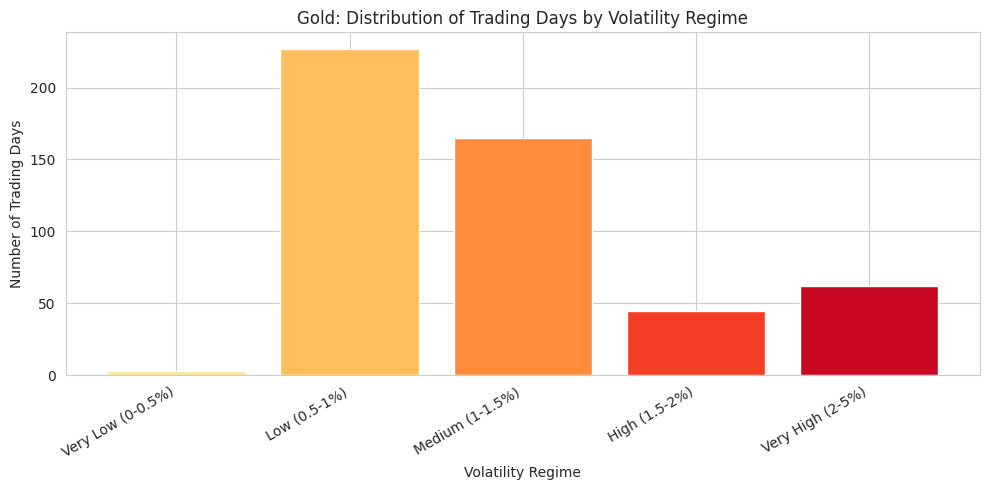

In [15]:
# ── MQ3: Classify trading days into volatility regimes ──
# Demonstrates: $bucket aggregation, statistical grouping
# FIX: F_RETURN now correctly maps to daily_return_pct

pipeline_mq3 = [
    {'$match': {
        'asset_name': GOLD,
        P_VOL21: {'$exists': True, '$ne': None}
    }},
    {'$bucket': {
        'groupBy':    F_VOL21,
        'boundaries': [0, 0.005, 0.01, 0.015, 0.02, 0.05, 1.0],
        'default':    'outlier',
        'output': {
            'count':      {'$sum': 1},
            'avg_return': {'$avg': F_RETURN},   # FIX: daily_return_pct
            'avg_close':  {'$avg': F_CLOSE},
            'avg_rsi':    {'$avg': F_RSI}
        }
    }}
]

result_mq3 = list(db['integrated_data'].aggregate(pipeline_mq3))

regime_labels = {
    0:     'Very Low (0-0.5%)',
    0.005: 'Low (0.5-1%)',
    0.01:  'Medium (1-1.5%)',
    0.015: 'High (1.5-2%)',
    0.02:  'Very High (2-5%)',
    0.05:  'Extreme (>5%)'
}

df_mq3 = pd.DataFrame(result_mq3)
if not df_mq3.empty:
    df_mq3['regime'] = df_mq3['_id'].map(regime_labels).fillna('Outlier')
    display(Markdown('### MQ3: Gold Volatility Regime Distribution'))
    display(Markdown('**Pipeline:** `$match` -> `$bucket` (volatility bins with aggregate stats)'))
    display(df_mq3[['regime', 'count', 'avg_return', 'avg_close', 'avg_rsi']])

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(df_mq3['regime'], df_mq3['count'],
           color=sns.color_palette('YlOrRd', len(df_mq3)))
    ax.set_xlabel('Volatility Regime')
    ax.set_ylabel('Number of Trading Days')
    ax.set_title('Gold: Distribution of Trading Days by Volatility Regime')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('data/exports/mq3_volatility_regimes.png', dpi=150)
    plt.show()
else:
    print('No volatility data available.')

### MQ4: Gold vs Silver Performance Comparison with `$facet`

In [16]:
# ── MQ4: Multi-asset comparison with $facet ──
# Demonstrates: $facet for parallel aggregation pipelines
# FIX: F_RETURN now daily_return_pct

pipeline_mq4 = [
    {'$match': {'asset_name': {'$in': [GOLD, SILVER]}}},
    {'$facet': {
        'summary_stats': [
            {'$group': {
                '_id':             '$asset_name',
                'total_days':      {'$sum': 1},
                'avg_close':       {'$avg': F_CLOSE},
                'max_close':       {'$max': F_CLOSE},
                'min_close':       {'$min': F_CLOSE},
                'avg_volume':      {'$avg': F_VOLUME},
                'avg_daily_return':{'$avg': F_RETURN},   # FIX
                'avg_rsi':         {'$avg': F_RSI},
                'avg_volatility':  {'$avg': F_VOL21}
            }}
        ],
        'recent_trend': [
            {'$sort':  {'date': -1}},
            {'$limit': 20},
            {'$group': {
                '_id':              '$asset_name',
                'recent_avg_close': {'$avg': F_CLOSE},
                'recent_avg_return':{'$avg': F_RETURN},  # FIX
                'latest_date':      {'$max': '$date'}
            }}
        ]
    }}
]

result_mq4 = list(db['integrated_data'].aggregate(pipeline_mq4))

display(Markdown('### MQ4: Gold vs Silver — Full Period Statistics'))
display(Markdown('**Pipeline:** `$match` -> `$facet` (parallel: summary_stats + recent_trend)'))

if result_mq4:
    facet      = result_mq4[0]
    df_summary = pd.DataFrame(facet['summary_stats']).rename(columns={'_id': 'Asset'})
    display(df_summary)

    print('\n--- Recent Trend (Last 20 Trading Days per Asset) ---')
    df_recent = pd.DataFrame(facet['recent_trend']).rename(columns={'_id': 'Asset'})
    display(df_recent)

### MQ4: Gold vs Silver — Full Period Statistics

**Pipeline:** `$match` -> `$facet` (parallel: summary_stats + recent_trend)

,Asset,total_days,avg_close,max_close,min_close,avg_volume,avg_daily_return,avg_rsi,avg_volatility
0,silver,504,41.2641,115.0800,24.6250,1419.0258,0.2591,56.3260,0.0253
1,gold,504,3247.2883,5318.3999,2190.6001,4192.4365,0.1553,59.8400,0.0124



--- Recent Trend (Last 20 Trading Days per Asset) ---


,Asset,recent_avg_close,recent_avg_return,latest_date
0,gold,4632.5300,-1.0196,2026-03-27
1,silver,72.6068,-1.3063,2026-03-27


### MQ5: RSI Overbought/Oversold Signal Detection

In [17]:
# ── MQ5: RSI extreme days ──
# Demonstrates: $match with range queries, $addFields

pipeline_mq5 = [
    {'$match': {
        'asset_name': GOLD,
        P_RSI: {'$exists': True, '$ne': None},
        '$or': [
            {P_RSI: {'$gte': 70}},
            {P_RSI: {'$lte': 30}}
        ]
    }},
    {'$addFields': {
        'signal': {
            '$cond': [{'$gte': [F_RSI, 70]}, 'OVERBOUGHT', 'OVERSOLD']
        }
    }},
    {'$project': {
        '_id':          0,
        'date':         1,
        'signal':       1,
        'close':        F_CLOSE,
        'rsi':          F_RSI,
        'daily_return': F_RETURN   # FIX: daily_return_pct
    }},
    {'$sort': {'date': -1}}
]

result_mq5 = list(db['integrated_data'].aggregate(pipeline_mq5))
df_mq5     = pd.DataFrame(result_mq5)

display(Markdown('### MQ5: Gold RSI Extreme Signal Days'))

if not df_mq5.empty:
    df_mq5['date'] = pd.to_datetime(df_mq5['date']).dt.strftime('%Y-%m-%d')
    overbought = df_mq5[df_mq5['signal'] == 'OVERBOUGHT']
    oversold   = df_mq5[df_mq5['signal'] == 'OVERSOLD']

    print(f'Total extreme RSI days: {len(df_mq5)}')
    print(f'  Overbought (RSI >= 70): {len(overbought)}')
    print(f'  Oversold   (RSI <= 30): {len(oversold)}')
    print(f'\nMost recent 10 signals:')
    display(df_mq5.head(10))
else:
    print('No RSI extreme days found.')

### MQ5: Gold RSI Extreme Signal Days

Total extreme RSI days: 138
  Overbought (RSI >= 70): 126
  Oversold   (RSI <= 30): 12

Most recent 10 signals:


,date,signal,close,rsi,daily_return
0,2026-03-26,OVERSOLD,4375.5000,21.7107,-3.8309
1,2026-03-25,OVERSOLD,4549.7998,29.6807,3.4210
2,2026-03-24,OVERSOLD,4399.2998,19.2685,-0.1090
3,2026-03-23,OVERSOLD,4404.1001,20.2219,-3.6386
4,2026-03-20,OVERSOLD,4570.3999,19.8735,-0.6586
5,2026-03-19,OVERSOLD,4600.7002,24.5062,-5.9142
6,2026-02-23,OVERBOUGHT,5204.7002,70.9485,2.8739
7,2026-01-29,OVERBOUGHT,5318.3999,94.5625,0.3169
8,2026-01-28,OVERBOUGHT,5301.6001,94.4694,4.3643
9,2026-01-27,OVERBOUGHT,5079.8999,88.8369,0.0039


### MQ6: Sentiment Distribution Analysis

In [18]:
# ── MQ6: Sentiment statistics per asset ──
# Demonstrates: $stdDevPop in aggregation
# FIX: P_SENT now correctly refers to 'sentiment.mean'

pipeline_mq6 = [
    {'$match': {
        P_SENT: {'$exists': True, '$ne': None, '$gt': 0}   # only days WITH real news
    }},
    {'$group': {
        '_id':              '$asset_name',
        'days_with_sentiment': {'$sum': 1},
        'avg_compound':     {'$avg':       F_SENT},
        'stddev_compound':  {'$stdDevPop': F_SENT},
        'max_compound':     {'$max':       F_SENT},
        'min_compound':     {'$min':       F_SENT},
        'avg_news_count':   {'$avg':       F_NCNT},
        'total_news':       {'$sum':       F_NCNT}
    }},
    {'$sort': {'days_with_sentiment': -1}}
]

result_mq6 = list(db['integrated_data'].aggregate(pipeline_mq6))
df_mq6     = pd.DataFrame(result_mq6).rename(columns={'_id': 'Asset'})

display(Markdown('### MQ6: Sentiment Statistics per Asset'))
display(Markdown('**Pipeline:** `$match` (sentiment > 0) -> `$group` with `$stdDevPop` -> `$sort`'))
display(df_mq6)

### MQ6: Sentiment Statistics per Asset

**Pipeline:** `$match` (sentiment > 0) -> `$group` with `$stdDevPop` -> `$sort`

,Asset,days_with_sentiment,avg_compound,stddev_compound,max_compound,min_compound,avg_news_count,total_news
0,dxy,29,0.2440,0.1689,0.5719,0.0256,2.1724,63
1,silver,29,0.2440,0.1689,0.5719,0.0256,2.1724,63
2,gold,29,0.2440,0.1689,0.5719,0.0256,2.1724,63
3,sp500,29,0.2440,0.1689,0.5719,0.0256,2.1724,63


### MQ7: Volume-Weighted Average Price (VWAP)

### MQ7: Monthly VWAP — Gold

**Pipeline:** `$match` -> `$project` (typical price, P*V) -> `$group` -> `$addFields` (VWAP) -> `$sort`

,Month,vwap,avg_typical_price,total_volume,days
0,2026-03,4551.1466,4890.5750,181344,20
1,2026-02,4952.4737,5005.4123,20482,19
2,2026-01,5221.8747,4737.7233,159292,20
3,2025-12,4309.3824,4310.4061,21215,22
4,2025-11,4138.5943,4082.9704,169699,18
5,2025-10,4078.6269,4046.1957,42621,23
6,2025-09,3759.9956,3676.5286,38627,21
7,2025-08,3383.0553,3365.5767,36288,20
8,2025-07,3319.8894,3340.6238,142774,21
9,2025-06,3349.3058,3348.7105,21971,19


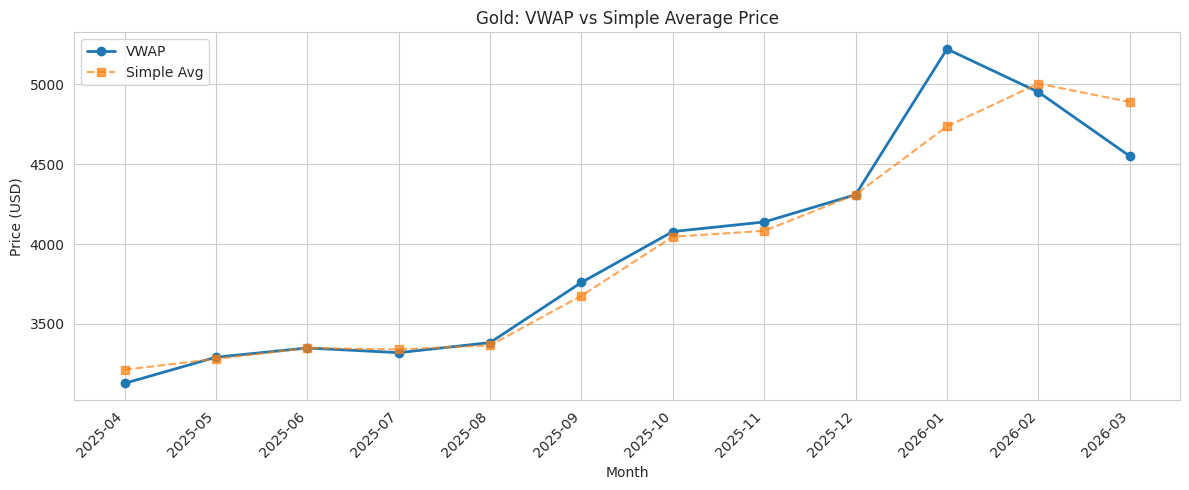

In [19]:
# ── MQ7: Monthly VWAP ──
# Demonstrates: computed fields with $multiply, $divide, $addFields

pipeline_mq7 = [
    {'$match': {
        'asset_name': GOLD,
        P_VOLUME: {'$gt': 0}
    }},
    {'$project': {
        'year_month':    {'$dateToString': {'format': '%Y-%m', 'date': '$date'}},
        'typical_price': {
            '$divide': [{'$add': [F_HIGH, F_LOW, F_CLOSE]}, 3]
        },
        'volume': F_VOLUME,
        'pv': {
            '$multiply': [
                {'$divide': [{'$add': [F_HIGH, F_LOW, F_CLOSE]}, 3]},
                F_VOLUME
            ]
        }
    }},
    {'$group': {
        '_id':               '$year_month',
        'total_pv':          {'$sum': '$pv'},
        'total_volume':      {'$sum': '$volume'},
        'avg_typical_price': {'$avg': '$typical_price'},
        'days':              {'$sum': 1}
    }},
    {'$addFields': {
        'vwap': {'$cond': [
            {'$gt': ['$total_volume', 0]},
            {'$divide': ['$total_pv', '$total_volume']},
            None
        ]}
    }},
    {'$sort':  {'_id': -1}},
    {'$limit': 12}
]

result_mq7 = list(db['integrated_data'].aggregate(pipeline_mq7))
df_mq7     = pd.DataFrame(result_mq7).rename(columns={'_id': 'Month'})

display(Markdown('### MQ7: Monthly VWAP — Gold'))
display(Markdown('**Pipeline:** `$match` -> `$project` (typical price, P*V) -> `$group` -> `$addFields` (VWAP) -> `$sort`'))

if not df_mq7.empty:
    display(df_mq7[['Month', 'vwap', 'avg_typical_price', 'total_volume', 'days']])

    fig, ax = plt.subplots(figsize=(12, 5))
    df_plot = df_mq7.sort_values('Month')
    ax.plot(df_plot['Month'], df_plot['vwap'],          'o-',  label='VWAP',       linewidth=2)
    ax.plot(df_plot['Month'], df_plot['avg_typical_price'], 's--', label='Simple Avg', linewidth=1.5, alpha=0.7)
    ax.set_xlabel('Month')
    ax.set_ylabel('Price (USD)')
    ax.set_title('Gold: VWAP vs Simple Average Price')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('data/exports/mq7_vwap.png', dpi=150)
    plt.show()
else:
    print('No VWAP data — volume field may be missing.')

## 5. Advanced Neo4j Cypher Queries
### CQ1: Longest Consecutive Bullish Streak

In [20]:
# ── CQ1: Longest bullish streaks via NEXT_DAY temporal chain ──
# Demonstrates: variable-length path traversal, ALL() predicate
# FIX: n.open → n.open_price (TradingDay stores open price as open_price)

cq1_query = """
MATCH path = (start:TradingDay)-[:NEXT_DAY*1..30]->(end:TradingDay)
WHERE ALL(n IN nodes(path) WHERE n.close > n.open_price)
WITH path, length(path) AS streak_len,
     nodes(path)[0]  AS first_day,
     nodes(path)[-1] AS last_day
RETURN first_day.date  AS start_date,
       last_day.date   AS end_date,
       streak_len      AS consecutive_bullish_days,
       first_day.close AS start_close,
       last_day.close  AS end_close,
       round((last_day.close - first_day.close) / first_day.close * 100, 2) AS pct_gain
ORDER BY streak_len DESC
LIMIT 10
"""

result_cq1 = graph.run(cq1_query).data()
df_cq1     = pd.DataFrame(result_cq1)

display(Markdown('### CQ1: Longest Consecutive Bullish Streaks'))
display(Markdown('**Graph advantage:** NEXT_DAY temporal chain makes streak detection natural — no self-joins needed.'))
display(Markdown('**Fix applied:** `n.close > n.open_price` (correct property name in TradingDay nodes).'))

if not df_cq1.empty:
    display(df_cq1)
else:
    print('No consecutive bullish streaks found (all days have close <= open_price).')

### CQ1: Longest Consecutive Bullish Streaks

**Graph advantage:** NEXT_DAY temporal chain makes streak detection natural — no self-joins needed.

**Fix applied:** `n.close > n.open_price` (correct property name in TradingDay nodes).

,start_date,end_date,consecutive_bullish_days,start_close,end_close,pct_gain
0,2025-08-22,2025-09-08,10,3374.3999,3638.1001,7.8100
1,2025-08-22,2025-09-05,9,3374.3999,3613.2000,7.0800
2,2025-08-25,2025-09-08,9,3373.8000,3638.1001,7.8300
3,2025-08-22,2025-09-04,8,3374.3999,3565.8000,5.6700
4,2025-08-25,2025-09-05,8,3373.8000,3613.2000,7.1000
5,2025-08-26,2025-09-08,8,3388.6001,3638.1001,7.3600
6,2025-01-14,2025-01-24,7,2677.5000,2777.3000,3.7300
7,2025-08-22,2025-09-03,7,3374.3999,3593.2000,6.4800
8,2025-08-25,2025-09-04,7,3373.8000,3565.8000,5.6900
9,2025-08-26,2025-09-05,7,3388.6001,3613.2000,6.6300


### CQ2: Sentiment Impact — Next-Day Price Movement

In [21]:
# ── CQ2: Sentiment -> next-day price direction ──
# Demonstrates: multi-hop pattern matching across node types
# FIX: s.avg_compound → s.sentiment_mean (DailySentiment property name)

cq2_query = f"""
MATCH (a:Asset {{name: '{NEO_GOLD}'}})-[:HAS_TRADING_DAY]->(td1:TradingDay)-[:NEXT_DAY]->(td2:TradingDay),
      (td1)-[:HAS_SENTIMENT]->(s:DailySentiment)
WITH td1, td2, s,
     CASE
       WHEN s.sentiment_mean > 0.05  THEN 'Positive'
       WHEN s.sentiment_mean < -0.05 THEN 'Negative'
       ELSE 'Neutral'
     END AS sentiment_class,
     CASE
       WHEN td2.close > td1.close THEN 'Up'
       WHEN td2.close < td1.close THEN 'Down'
       ELSE 'Flat'
     END AS next_day_direction
RETURN sentiment_class,
       next_day_direction,
       count(*) AS occurrences,
       round(avg(td2.close - td1.close), 2) AS avg_price_change,
       round(avg((td2.close - td1.close) / td1.close * 100), 4) AS avg_pct_change
ORDER BY sentiment_class, next_day_direction
"""

result_cq2 = graph.run(cq2_query).data()
df_cq2     = pd.DataFrame(result_cq2)

display(Markdown('### CQ2: Sentiment → Next-Day Price Direction'))
display(Markdown('**Graph advantage:** `(Asset)->(TradingDay)->(NextDay)` + `(TradingDay)->(Sentiment)` in a single MATCH.'))
display(Markdown('**Fix applied:** `s.sentiment_mean` (correct DailySentiment property name).'))

if not df_cq2.empty:
    display(df_cq2)
    pivot = df_cq2.pivot_table(index='sentiment_class', columns='next_day_direction',
                                values='occurrences', fill_value=0)
    print('\nPivot — Sentiment vs Next-Day Direction:')
    display(pivot)
else:
    print('No sentiment->price patterns found.')

### CQ2: Sentiment → Next-Day Price Direction

**Graph advantage:** `(Asset)->(TradingDay)->(NextDay)` + `(TradingDay)->(Sentiment)` in a single MATCH.

**Fix applied:** `s.sentiment_mean` (correct DailySentiment property name).

,sentiment_class,next_day_direction,occurrences,avg_price_change,avg_pct_change
0,Negative,Down,9,-62.7900,-1.2801
1,Negative,Up,15,97.7900,2.1554
2,Neutral,Down,8,-66.7500,-1.5089
3,Neutral,Up,19,49.6100,1.0865
4,Positive,Down,10,-123.0200,-2.5087
5,Positive,Up,15,61.1000,1.3748



Pivot — Sentiment vs Next-Day Direction:


next_day_direction,Down,Up
sentiment_class,,
Negative,9.0000,15.0000
Neutral,8.0000,19.0000
Positive,10.0000,15.0000


### CQ3: Weekly Price Trend via Temporal Chain Aggregation

In [22]:
# ── CQ3: 5-day window aggregation via NEXT_DAY chains ──
# Demonstrates: reduce() over path nodes

cq3_query = f"""
MATCH (a:Asset {{name: '{NEO_GOLD}'}})-[:HAS_TRADING_DAY]->(start:TradingDay)
MATCH path = (start)-[:NEXT_DAY*4]->(end:TradingDay)
WITH start, end, nodes(path) AS week_days
WITH start.date  AS week_start,
     end.date    AS week_end,
     start.close AS open_price,
     end.close   AS close_price,
     reduce(mx = 0,      n IN week_days | CASE WHEN n.high > mx         THEN n.high ELSE mx END) AS week_high,
     reduce(mn = 999999, n IN week_days | CASE WHEN n.low < mn          THEN n.low  ELSE mn END) AS week_low,
     reduce(tv = 0,      n IN week_days | tv + coalesce(n.volume, 0))                            AS week_volume
RETURN week_start, week_end,
       round(open_price,  2) AS open_price,
       round(close_price, 2) AS close_price,
       round(week_high,   2) AS week_high,
       round(week_low,    2) AS week_low,
       week_volume,
       round((close_price - open_price) / open_price * 100, 2) AS weekly_return_pct
ORDER BY week_start DESC
LIMIT 15
"""

result_cq3 = graph.run(cq3_query).data()
df_cq3     = pd.DataFrame(result_cq3)

display(Markdown('### CQ3: 5-Day (Weekly) OHLCV Aggregation via Graph Traversal'))
display(Markdown('**Graph advantage:** `reduce()` over nodes in a path — no date arithmetic needed.'))

if not df_cq3.empty:
    display(df_cq3)
else:
    print('No 5-day windows found.')

### CQ3: 5-Day (Weekly) OHLCV Aggregation via Graph Traversal

**Graph advantage:** `reduce()` over nodes in a path — no date arithmetic needed.

,week_start,week_end,open_price,close_price,week_high,week_low,week_volume,weekly_return_pct
0,2026-03-23,2026-03-27,4404.1000,4540.6000,4585.3000,4100.8000,167815,3.1000
1,2026-03-20,2026-03-26,4570.4000,4375.5000,4686.9000,4100.8000,1933,-4.2600
2,2026-03-19,2026-03-25,4600.7000,4549.8000,4830.3000,4100.8000,2172,-1.1100
3,2026-03-18,2026-03-24,4889.9000,4399.3000,4949.6000,4100.8000,3245,-10.0300
4,2026-03-17,2026-03-23,5001.0000,4404.1000,5017.6000,4100.8000,3106,-11.9400
5,2026-03-16,2026-03-20,4994.0000,4570.4000,5017.6000,4554.0000,2692,-8.4800
6,2026-03-13,2026-03-19,5052.5000,4600.7000,5117.0000,4554.0000,2936,-8.9400
7,2026-03-12,2026-03-18,5115.8000,4889.9000,5137.2000,4821.7000,2719,-4.4200
8,2026-03-11,2026-03-17,5167.4000,5001.0000,5191.3000,4994.0000,1891,-3.2200
9,2026-03-10,2026-03-16,5229.7000,4994.0000,5229.7000,4994.0000,5952,-4.5100


### CQ4: Cross-Asset Correlation Network

In [23]:
# ── CQ4: Query correlation network ──
# Demonstrates: relationship property queries

cq4_query = """
MATCH (a1:Asset)-[c:CORRELATES_WITH]->(a2:Asset)
RETURN a1.name                AS asset_1,
       a2.name                AS asset_2,
       round(c.correlation, 4) AS correlation,
       CASE
         WHEN c.correlation >  0.7 THEN 'Strong Positive'
         WHEN c.correlation >  0.3 THEN 'Moderate Positive'
         WHEN c.correlation > -0.3 THEN 'Weak / None'
         WHEN c.correlation > -0.7 THEN 'Moderate Negative'
         ELSE 'Strong Negative'
       END AS strength
ORDER BY abs(c.correlation) DESC
"""

result_cq4 = graph.run(cq4_query).data()
df_cq4     = pd.DataFrame(result_cq4)

display(Markdown('### CQ4: Inter-Asset Correlation Network'))
display(Markdown('**Graph advantage:** Correlations as edge properties — full network in one pattern match.'))

if not df_cq4.empty:
    display(df_cq4)
else:
    print('No CORRELATES_WITH relationships found.')

### CQ4: Inter-Asset Correlation Network

**Graph advantage:** Correlations as edge properties — full network in one pattern match.

,asset_1,asset_2,correlation,strength
0,gold,silver,0.9233,Strong Positive
1,gold,sp500,0.8778,Strong Positive
2,silver,sp500,0.7877,Strong Positive
3,dxy,gold,-0.7283,Strong Negative
4,dxy,sp500,-0.6213,Moderate Negative
5,dxy,silver,-0.5810,Moderate Negative


### CQ5: High-Sentiment Trading Windows

In [24]:
# ── CQ5: 3-day windows with consistently strong sentiment ──
# Demonstrates: multi-hop patterns with filtering at each node
# FIX: s1.avg_compound → s1.sentiment_mean (DailySentiment property name)

cq5_query = f"""
MATCH (a:Asset {{name: '{NEO_GOLD}'}})-[:HAS_TRADING_DAY]->(d1:TradingDay)-[:NEXT_DAY]->(d2:TradingDay)-[:NEXT_DAY]->(d3:TradingDay),
      (d1)-[:HAS_SENTIMENT]->(s1:DailySentiment),
      (d2)-[:HAS_SENTIMENT]->(s2:DailySentiment),
      (d3)-[:HAS_SENTIMENT]->(s3:DailySentiment)
WHERE abs(s1.sentiment_mean) > 0.1
  AND abs(s2.sentiment_mean) > 0.1
  AND abs(s3.sentiment_mean) > 0.1
RETURN d1.date AS day_1, d2.date AS day_2, d3.date AS day_3,
       round(s1.sentiment_mean, 4) AS sent_1,
       round(s2.sentiment_mean, 4) AS sent_2,
       round(s3.sentiment_mean, 4) AS sent_3,
       round(d1.close, 2) AS close_1,
       round(d3.close, 2) AS close_3,
       round((d3.close - d1.close) / d1.close * 100, 2) AS window_return_pct
ORDER BY abs(s1.sentiment_mean) + abs(s2.sentiment_mean) + abs(s3.sentiment_mean) DESC
LIMIT 10
"""

result_cq5 = graph.run(cq5_query).data()
df_cq5     = pd.DataFrame(result_cq5)

display(Markdown('### CQ5: 3-Day High-Sentiment Windows'))
display(Markdown('**Graph advantage:** Multi-hop pattern with sentiment check at each node.'))
display(Markdown('**Fix applied:** `s.sentiment_mean` (correct DailySentiment property name).'))

if not df_cq5.empty:
    display(df_cq5)
else:
    print('No 3-day high-sentiment windows found (low sentiment coverage ~15.3%).')

### CQ5: 3-Day High-Sentiment Windows

**Graph advantage:** Multi-hop pattern with sentiment check at each node.

**Fix applied:** `s.sentiment_mean` (correct DailySentiment property name).

,day_1,day_2,day_3,sent_1,sent_2,sent_3,close_1,close_3,window_return_pct
0,2026-03-02,2026-03-03,2026-03-04,-0.7783,0.1609,-0.6908,5294.4000,5120.2000,-3.2900
1,2026-02-02,2026-02-03,2026-02-04,-0.5719,-0.1005,0.5719,4622.5000,4920.4000,6.4400
2,2026-01-29,2026-01-30,2026-02-02,0.1779,0.3404,-0.5719,5318.4000,4622.5000,-13.0800
3,2026-01-30,2026-02-02,2026-02-03,0.3404,-0.5719,-0.1005,4713.9000,4903.7000,4.0300
4,2026-03-03,2026-03-04,2026-03-05,0.1609,-0.6908,-0.1093,5107.4000,5065.3000,-0.8200
5,2025-12-23,2025-12-24,2025-12-26,-0.3182,0.1027,0.4767,4482.8000,4529.1000,1.0300
6,2025-12-24,2025-12-26,2025-12-29,0.1027,0.4767,0.2810,4480.6000,4325.1000,-3.4700
7,2025-12-19,2025-12-22,2025-12-23,-0.2202,0.1591,-0.3182,4361.4000,4482.8000,2.7800
8,2025-12-31,2026-01-02,2026-01-05,0.2732,-0.1480,-0.2144,4325.6000,4436.9000,2.5700
9,2026-03-24,2026-03-25,2026-03-26,-0.3105,0.2006,-0.1112,4399.3000,4375.5000,-0.5400


### CQ6: Graph Structure Statistics

In [25]:
# ── CQ6: Graph-level statistics ──

cq6_query = """
MATCH (td:TradingDay)
WITH td,
     size([(td)-[:NEXT_DAY]->()  | 1]) AS out_next,
     size([(td)<-[:NEXT_DAY]-()  | 1]) AS in_next,
     size([(td)-[:HAS_SENTIMENT]->() | 1]) AS has_sentiment
RETURN
  count(td) AS total_trading_days,
  sum(CASE WHEN has_sentiment > 0 THEN 1 ELSE 0 END) AS days_with_sentiment,
  sum(CASE WHEN out_next = 0 THEN 1 ELSE 0 END) AS chain_endpoints,
  sum(CASE WHEN in_next  = 0 THEN 1 ELSE 0 END) AS chain_starts,
  round(toFloat(sum(CASE WHEN has_sentiment > 0 THEN 1 ELSE 0 END)) / count(td) * 100, 1) AS sentiment_coverage_pct
"""

result_cq6 = graph.run(cq6_query).data()

display(Markdown('### CQ6: Graph Structure Statistics'))

if result_cq6:
    stats = result_cq6[0]
    print('Neo4j Graph Structure Summary:')
    for k, v in stats.items():
        label = k.replace('_', ' ').title()
        print(f'  {label}: {v}')

### CQ6: Graph Structure Statistics

Neo4j Graph Structure Summary:
  Total Trading Days: 504
  Days With Sentiment: 77
  Chain Endpoints: 1
  Chain Starts: 1
  Sentiment Coverage Pct: 15.3


### CQ7: Price Recovery After Drops

In [26]:
# ── CQ7: Recovery time after significant drops (>1.5%) ──
# Demonstrates: conditional path traversal
# FIX: drop_day.open → drop_day.open_price (TradingDay property name)

cq7_query = f"""
MATCH (a:Asset {{name: '{NEO_GOLD}'}})-[:HAS_TRADING_DAY]->(drop_day:TradingDay)
WHERE drop_day.close < drop_day.open_price
  AND (drop_day.open_price - drop_day.close) / drop_day.open_price > 0.015
OPTIONAL MATCH path = (drop_day)-[:NEXT_DAY*1..10]->(recovery:TradingDay)
WHERE recovery.close >= drop_day.open_price
WITH drop_day,
     min(length(path)) AS fastest_recovery
RETURN drop_day.date AS drop_date,
       round(drop_day.open_price, 2) AS open_price,
       round(drop_day.close,      2) AS close_price,
       round((drop_day.open_price - drop_day.close) / drop_day.open_price * 100, 2) AS drop_pct,
       CASE WHEN fastest_recovery IS NOT NULL
            THEN fastest_recovery
            ELSE 'No recovery within 10 days'
       END AS recovery_days
ORDER BY drop_day.date DESC
LIMIT 15
"""

result_cq7 = graph.run(cq7_query).data()
df_cq7     = pd.DataFrame(result_cq7)

display(Markdown('### CQ7: Price Recovery After Significant Drops (>1.5%)'))
display(Markdown('**Graph advantage:** Follow NEXT_DAY chain until price recovers — naturally expressed as a graph pattern.'))
display(Markdown('**Fix applied:** `drop_day.open_price` (correct TradingDay property name).'))

if not df_cq7.empty:
    display(df_cq7)
else:
    print('No significant intraday drop days found (check open_price vs close).')

### CQ7: Price Recovery After Significant Drops (>1.5%)

**Graph advantage:** Follow NEXT_DAY chain until price recovers — naturally expressed as a graph pattern.

**Fix applied:** `drop_day.open_price` (correct TradingDay property name).

,drop_date,open_price,close_price,drop_pct,recovery_days
0,2026-03-20,4686.9000,4570.4000,2.4900,No recovery within 10 days
1,2026-03-19,4830.3000,4600.7000,4.7500,No recovery within 10 days
2,2026-03-05,5169.5000,5065.3000,2.0200,3
3,2026-03-03,5298.7000,5107.4000,3.6100,No recovery within 10 days
4,2026-02-17,5020.0000,4882.9000,2.7300,3
5,2026-02-12,5060.4000,4923.7000,2.7000,6
6,2026-02-05,5008.7000,4861.4000,2.9400,2
7,2026-02-02,4807.7000,4622.5000,3.8500,1
8,2026-01-30,5376.4000,4713.9000,12.3200,No recovery within 10 days
9,2026-01-29,5415.7000,5318.4000,1.8000,No recovery within 10 days


## 6. Cross-Database Query Comparison

In [27]:
# ── Same question on both DBMS: monthly avg close + avg sentiment ──
import time

# --- MongoDB ---
t0 = time.time()
pipeline_cross = [
    {'$match': {
        'asset_name': GOLD,
        P_SENT: {'$exists': True, '$ne': None}
    }},
    {'$project': {
        'month':     {'$dateToString': {'format': '%Y-%m', 'date': '$date'}},
        'close':     F_CLOSE,
        'sentiment': F_SENT    # FIX: sentiment.mean
    }},
    {'$group': {
        '_id':           '$month',
        'avg_close':     {'$avg': '$close'},
        'avg_sentiment': {'$avg': '$sentiment'},
        'days':          {'$sum': 1}
    }},
    {'$sort':  {'_id': -1}},
    {'$limit': 6}
]
mongo_result = list(db['integrated_data'].aggregate(pipeline_cross))
mongo_time   = time.time() - t0

# --- Neo4j ---
# FIX: s.sentiment_mean instead of s.avg_compound
t0 = time.time()
neo4j_cross_query = f"""
MATCH (a:Asset {{name: '{NEO_GOLD}'}})-[:HAS_TRADING_DAY]->(td:TradingDay)-[:HAS_SENTIMENT]->(s:DailySentiment)
WITH td, s,
     substring(td.date, 0, 7) AS month
RETURN month,
       round(avg(td.close),          2) AS avg_close,
       round(avg(s.sentiment_mean),  4) AS avg_sentiment,
       count(td)                        AS days
ORDER BY month DESC
LIMIT 6
"""
neo4j_result = graph.run(neo4j_cross_query).data()
neo4j_time   = time.time() - t0

display(Markdown('### Cross-Database: Monthly Avg Close + Avg Sentiment'))

print(f'MongoDB result ({mongo_time:.3f}s):')
display(pd.DataFrame(mongo_result).rename(columns={'_id': 'month'}))

print(f'\nNeo4j result ({neo4j_time:.3f}s):')
display(pd.DataFrame(neo4j_result))

print('\n--- Comparison ---')
print('MongoDB: Natural for aggregation pipelines on document fields.')
print('Neo4j:   Natural for traversing relationships (Asset->TradingDay->Sentiment).')
print('Both produce equivalent results; the best choice depends on the query pattern.')

### Cross-Database: Monthly Avg Close + Avg Sentiment

MongoDB result (0.036s):


,month,avg_close,avg_sentiment,days
0,2026-03,4885.7800,-0.0505,20
1,2026-02,5011.0368,-0.0229,19
2,2026-01,4730.8600,-0.0426,20
3,2025-12,4311.0591,0.0794,22
4,2025-11,4082.1158,-0.0058,19
5,2025-10,4044.3739,-0.0616,23



Neo4j result (0.439s):


,month,avg_close,avg_sentiment,days
0,2026-03,4873.3100,-0.0722,14
1,2026-02,4991.7600,-0.0335,13
2,2026-01,4733.5800,-0.0655,13
3,2025-12,4363.7600,0.1589,11
4,2025-11,4045.0700,-0.0185,6
5,2025-10,4033.1500,-0.1289,11



--- Comparison ---
MongoDB: Natural for aggregation pipelines on document fields.
Neo4j:   Natural for traversing relationships (Asset->TradingDay->Sentiment).
Both produce equivalent results; the best choice depends on the query pattern.


## 7. Query Summary & FAQ 6 Compliance

In [28]:
# ── Final summary ──
summary = {
    'MongoDB Queries': [
        'MQ1: Monthly price statistics (aggregation pipeline)',
        'MQ2: Sentiment-price divergence detection ($cond, $or) — FIXED',
        'MQ3: Volatility regime classification ($bucket)',
        'MQ4: Gold vs Silver comparison ($facet)',
        'MQ5: RSI overbought/oversold signal detection ($addFields)',
        'MQ6: Sentiment distribution with $stdDevPop — FIXED',
        'MQ7: Volume-Weighted Average Price (VWAP) computation'
    ],
    'Neo4j Cypher Queries': [
        'CQ1: Longest consecutive bullish streak (variable-length paths) — FIXED open_price',
        'CQ2: Sentiment impact on next-day price (multi-hop pattern matching) — FIXED sentiment_mean',
        'CQ3: 5-day window aggregation via NEXT_DAY chain (reduce over path)',
        'CQ4: Cross-asset correlation network (edge property queries)',
        'CQ5: High-sentiment trading windows (multi-node pattern filtering) — FIXED sentiment_mean',
        'CQ6: Graph structure statistics (degree distribution)',
        'CQ7: Price recovery after drops (conditional path traversal) — FIXED open_price'
    ]
}

display(Markdown('### Query Summary'))
for category, queries in summary.items():
    print(f'\n{category}:')
    for i, q in enumerate(queries, 1):
        print(f'  {i}. {q}')

print('\n' + '=' * 60)
print('FAQ 6 COMPLIANCE')
print('=' * 60)
print('Data modeled and stored in 2 DBMS: MongoDB (document) + Neo4j (graph)')
print('At least 2 queries: 7 MongoDB + 7 Neo4j + 1 cross-DB = 15 queries total')
print('Advanced patterns: $facet, $bucket, $stdDevPop, reduce(), variable-length paths')
print('=' * 60)

print('\n--- Fixes applied in this version ---')
print('  [MongoDB] F_SENT:   sentiment.avg_compound → sentiment.mean')
print('  [MongoDB] F_RETURN: technicals.daily_return → technicals.daily_return_pct')
print('  [Neo4j]   CQ1, CQ7: n.open → n.open_price')
print('  [Neo4j]   CQ2, CQ5: s.avg_compound → s.sentiment_mean')

### Query Summary


MongoDB Queries:
  1. MQ1: Monthly price statistics (aggregation pipeline)
  2. MQ2: Sentiment-price divergence detection ($cond, $or) — FIXED
  3. MQ3: Volatility regime classification ($bucket)
  4. MQ4: Gold vs Silver comparison ($facet)
  5. MQ5: RSI overbought/oversold signal detection ($addFields)
  6. MQ6: Sentiment distribution with $stdDevPop — FIXED
  7. MQ7: Volume-Weighted Average Price (VWAP) computation

Neo4j Cypher Queries:
  1. CQ1: Longest consecutive bullish streak (variable-length paths) — FIXED open_price
  2. CQ2: Sentiment impact on next-day price (multi-hop pattern matching) — FIXED sentiment_mean
  3. CQ3: 5-day window aggregation via NEXT_DAY chain (reduce over path)
  4. CQ4: Cross-asset correlation network (edge property queries)
  5. CQ5: High-sentiment trading windows (multi-node pattern filtering) — FIXED sentiment_mean
  6. CQ6: Graph structure statistics (degree distribution)
  7. CQ7: Price recovery after drops (conditional path traversal) — FIXED ope

In [29]:
# ── Cleanup ──
mongo_client.close()
print('Connections closed. Notebook 04 complete (v2 — all fixes applied).')

Connections closed. Notebook 04 complete (v2 — all fixes applied).
